# Demand Forecasting for Retail

## Analytical Report

**Author:** Elena Havrylova  
**Model:** LightGBM  
**Objective:** Build a production-ready demand forecasting pipeline for hourly retail demand prediction while preventing time-series data leakage.

This notebook documents:

- Exploratory Data Analysis
- Data preprocessing
- Feature engineering
- Stock-out / de-censoring logic
- 3-month backtest
- Baseline comparison
- Future Permutation Leakage Test
- Business interpretation

# 1. Business Problem

Accurate demand forecasting is one of the key components of inventory management.

Overestimating demand increases storage costs and product waste.

Underestimating demand leads to stock shortages, lost sales, and dissatisfied customers.

The objective of this project is to forecast hourly demand for every product in every dark store.

# 2. Setup and Imports

This section imports the project modules and external libraries.

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.append(str(PROJECT_ROOT))

import pandas as pd
import matplotlib.pyplot as plt

from src.data_loading import load_data, validate_schema
from src.preprocessing import clean_data, sort_time_series, add_stockout_flag
from src.features import build_features
from src.decensoring import create_demand_proxy, summarize_censoring
from src.training import train_and_evaluate
from src.validation import (
    evaluate_baselines,
    future_permutation_test,
    get_three_month_backtest_split,
)

# 3. Load Data

The dataset is loaded from the `data/` folder.

Expected file path:

`data/demand_train_val_1.5years.csv`

In [2]:
DATA_PATH = PROJECT_ROOT / "data" / "demand_train_val_1.5years.csv"

df = load_data(DATA_PATH)
validate_schema(df)

df.head()

,timestamp,store_id,product_id,temperature,local_event_factor,price,is_promo,competitor_price,delivery_delay_hours,holiday_factor,app_clicks,stock_on_hand,sales
0,2025-01-01 00:00:00,1,101,-5.954893,1.0,45.0,0,39.389910,0,5.006914,32.0,127,8
1,2025-01-01 01:00:00,1,101,-8.221485,1.0,40.0,0,43.727214,0,3.950974,29.0,119,7
2,2025-01-01 02:00:00,1,101,-3.560772,1.0,45.0,0,44.890532,0,0.298087,0.0,112,0
3,2025-01-01 03:00:00,1,101,-3.737111,1.0,40.0,0,38.710237,0,4.320862,NaN,112,8
4,2025-01-01 04:00:00,1,101,0.748672,1.0,40.0,0,39.771702,0,0.303396,0.0,164,0


# 4. Dataset Overview

The dataset contains historical sales together with operational and external variables, including weather, promotions, prices, inventory, and customer app activity.

In [3]:
print("Dataset shape:", df.shape)
print("\nDate range:")
print(df["timestamp"].min(), "to", df["timestamp"].max())

df.info()

Dataset shape: (78486, 13)

Date range:
2025-01-01 00:00:00 to 2026-06-30 00:00:00
<class 'pandas.DataFrame'>
RangeIndex: 78486 entries, 0 to 78485
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   timestamp             78486 non-null  datetime64[us]
 1   store_id              78486 non-null  int64         
 2   product_id            78486 non-null  int64         
 3   temperature           76601 non-null  float64       
 4   local_event_factor    78486 non-null  float64       
 5   price                 78486 non-null  float64       
 6   is_promo              78486 non-null  int64         
 7   competitor_price      66728 non-null  float64       
 8   delivery_delay_hours  78486 non-null  int64         
 9   holiday_factor        78486 non-null  float64       
 10  app_clicks            72117 non-null  float64       
 11  stock_on_hand         78486 non-null  int64         
 12  sa

In [4]:
df.describe(include="all")

,timestamp,store_id,product_id,temperature,local_event_factor,price,is_promo,competitor_price,delivery_delay_hours,holiday_factor,app_clicks,stock_on_hand,sales
count,78486,78486.000000,78486.000000,76601.000000,78486.000000,78486.000000,78486.000000,66728.000000,78486.000000,78486.000000,72117.000000,78486.000000,78486.000000
mean,2025-09-30 12:00:00,2.000000,101.500000,12.515442,1.008352,54.961107,0.099801,54.543671,0.157098,1.040394,60.877851,2277.523138,4.778304
min,2025-01-01 00:00:00,1.000000,101.000000,-13.139321,1.000000,32.300000,0.000000,18.596486,0.000000,0.101622,0.000000,0.000000,0.000000
25%,2025-05-17 06:00:00,1.000000,101.000000,3.335653,1.000000,40.000000,0.000000,39.872501,0.000000,1.000000,8.000000,0.000000,0.000000
50%,2025-09-30 12:00:00,2.000000,101.500000,12.240861,1.000000,51.400000,0.000000,48.254966,0.000000,1.000000,34.000000,40.000000,0.000000
75%,2026-02-13 18:00:00,3.000000,102.000000,21.723555,1.000000,70.000000,0.000000,69.868410,0.000000,1.000000,87.000000,3341.000000,6.000000
max,2026-06-30 00:00:00,3.000000,102.000000,39.566022,2.997826,75.000000,1.000000,83.100223,4.000000,5.998728,2712.000000,16860.000000,426.000000
std,NaN,0.816502,0.500003,10.571100,0.107749,15.150477,0.299737,15.400801,0.553962,0.414814,82.679351,4053.017920,9.730403


# 5. Exploratory Data Analysis

The goal of EDA is to understand missing values, sales patterns, seasonality, and potential stock-out situations before modeling.

## 5.1 Missing Values

Missing values are important because incomplete weather or competitor price data can affect model quality and pipeline stability.

In [5]:
missing_values = df.isna().sum().sort_values(ascending=False)
missing_values = missing_values[missing_values > 0]

missing_values

competitor_price    11758
app_clicks           6369
temperature          1885
dtype: int64

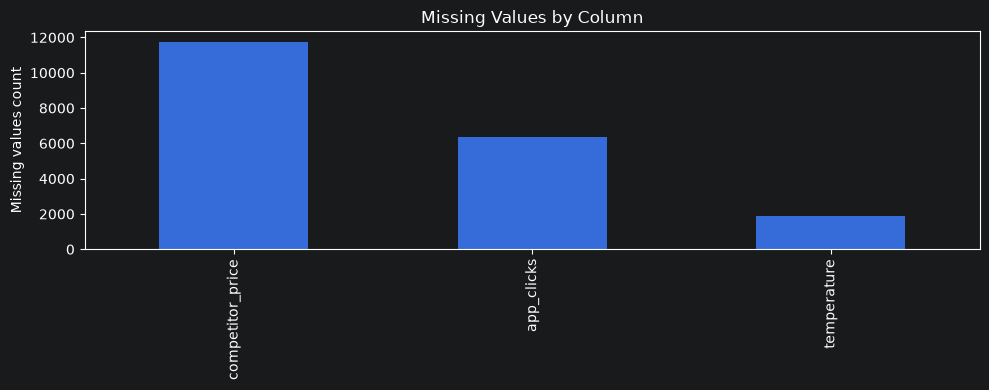

In [6]:
if len(missing_values) > 0:
    missing_values.plot(kind="bar", figsize=(10, 4))
    plt.title("Missing Values by Column")
    plt.ylabel("Missing values count")
    plt.tight_layout()
    plt.show()
else:
    print("No missing values found.")

**EDA interpretation**

Missing values require preprocessing before model training.  
The pipeline fills missing temperature values with the median and missing competitor prices with the company’s own product price.

## 5.2 Daily Sales Over Time

Daily sales help identify demand trends, seasonality, and abnormal periods.

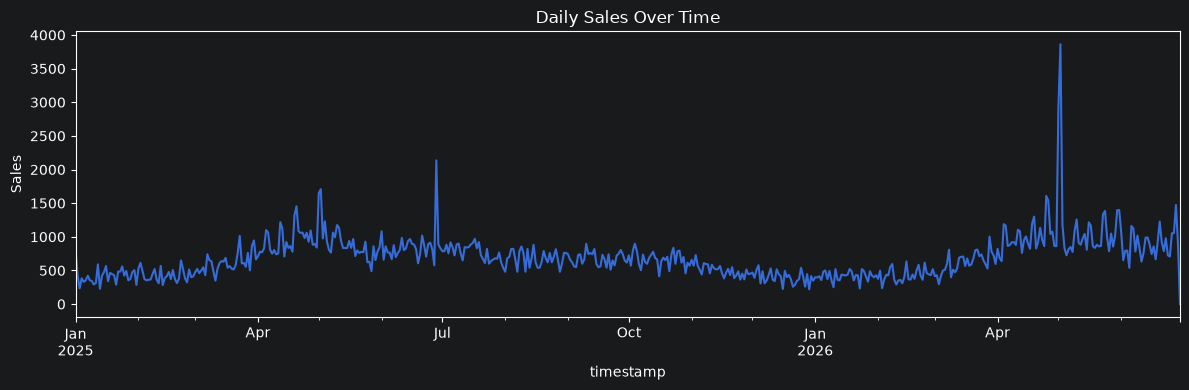

In [7]:
daily_sales = (
    df.set_index("timestamp")
    .resample("D")["sales"]
    .sum()
)

daily_sales.plot(figsize=(12, 4))
plt.title("Daily Sales Over Time")
plt.ylabel("Sales")
plt.tight_layout()
plt.show()

**EDA interpretation**

Daily sales visualization helps detect trend changes and demand fluctuations over time.  
This supports the use of time-based validation instead of random train/test split.

## 5.3 Average Sales by Hour

Hourly demand patterns are important for dark store inventory planning.

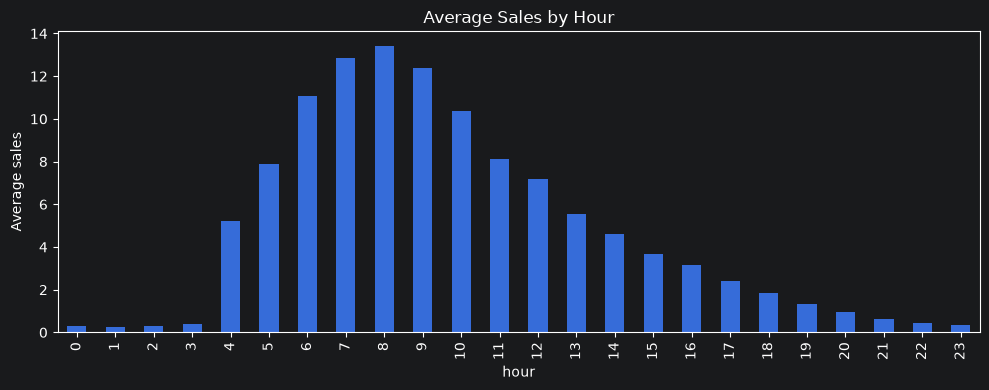

In [8]:
sales_by_hour = (
    df.assign(hour=df["timestamp"].dt.hour)
    .groupby("hour")["sales"]
    .mean()
)

sales_by_hour.plot(kind="bar", figsize=(10, 4))
plt.title("Average Sales by Hour")
plt.ylabel("Average sales")
plt.tight_layout()
plt.show()

**EDA interpretation**

Hourly sales patterns indicate that demand changes within the day.  
This supports the use of calendar features such as hour, day of week, and weekend indicator.

## 5.4 Sales Distribution

The sales distribution helps understand the scale of the target variable and the presence of extreme values.

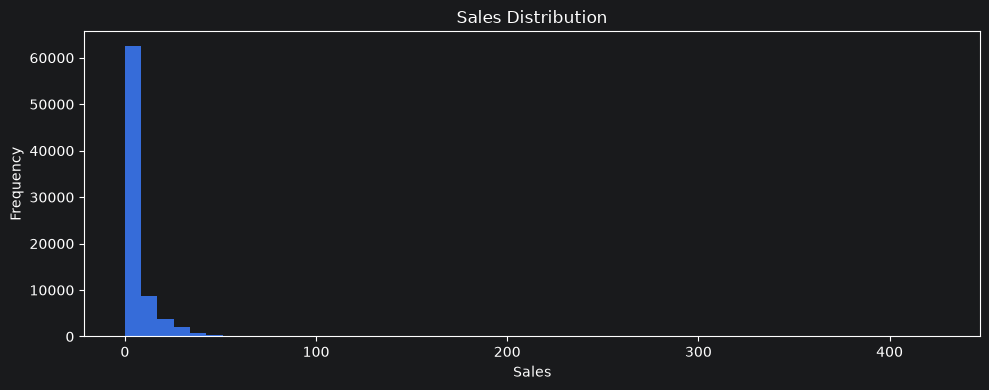

In [9]:
df["sales"].plot(kind="hist", bins=50, figsize=(10, 4))
plt.title("Sales Distribution")
plt.xlabel("Sales")
plt.tight_layout()
plt.show()

# 6. Data Preprocessing

The preprocessing stage includes:

- timestamp conversion;
- schema validation;
- missing value handling;
- chronological sorting;
- stock-out detection.

All preprocessing is performed without using future target information.

In [10]:
df_clean = clean_data(df)
df_clean = sort_time_series(df_clean)
df_clean = add_stockout_flag(df_clean)

df_clean.head()

,timestamp,store_id,product_id,temperature,local_event_factor,price,is_promo,competitor_price,delivery_delay_hours,holiday_factor,app_clicks,stock_on_hand,sales,is_stockout
0,2025-01-01 00:00:00,1,101,-5.954893,1.0,45.0,0,39.389910,0,5.006914,32.0,127,8,0
1,2025-01-01 01:00:00,1,101,-8.221485,1.0,40.0,0,43.727214,0,3.950974,29.0,119,7,0
2,2025-01-01 02:00:00,1,101,-3.560772,1.0,45.0,0,44.890532,0,0.298087,0.0,112,0,0
3,2025-01-01 03:00:00,1,101,-3.737111,1.0,40.0,0,38.710237,0,4.320862,0.0,112,8,0
4,2025-01-01 04:00:00,1,101,0.748672,1.0,40.0,0,39.771702,0,0.303396,0.0,164,0,0


# 7. Feature Engineering

The following feature groups were created:

- calendar features;
- pricing features;
- lag features;
- rolling statistics.

Special attention was paid to leakage prevention by using `shift(1)` before rolling windows.

In [11]:
df_features = build_features(df_clean)

feature_columns_preview = [
    "hour",
    "day_of_week",
    "month",
    "is_weekend",
    "price_diff",
    "price_ratio",
    "sales_lag_1h",
    "sales_lag_24h",
    "sales_lag_168h",
    "sales_rolling_mean_24h",
    "sales_rolling_std_24h",
]

df_features[feature_columns_preview].head()

,hour,day_of_week,month,is_weekend,price_diff,price_ratio,sales_lag_1h,sales_lag_24h,sales_lag_168h,sales_rolling_mean_24h,sales_rolling_std_24h
0,0,2,1,0,5.610090,1.142425,0.0,0.0,0.0,0.00,0.000000
1,1,2,1,0,-3.727214,0.914762,8.0,0.0,0.0,0.00,0.000000
2,2,2,1,0,0.109468,1.002439,7.0,0.0,0.0,0.00,0.000000
3,3,2,1,0,1.289763,1.033318,0.0,0.0,0.0,5.00,4.358899
4,4,2,1,0,0.228298,1.005740,8.0,0.0,0.0,5.75,3.862210


# 8. Stock-out / De-censoring Analysis

Observed sales are not always equal to real demand.

When `stock_on_hand = 0`, customers cannot purchase additional units, so actual sales may underestimate real demand.

To address this issue, stock-out observations are marked and a conservative demand proxy is created.

In [12]:
df_model = create_demand_proxy(df_features)

stockout_summary = summarize_censoring(df_model)
stockout_summary

{'total_rows': 78486, 'stockout_rows': 35381, 'stockout_share': 0.4508}

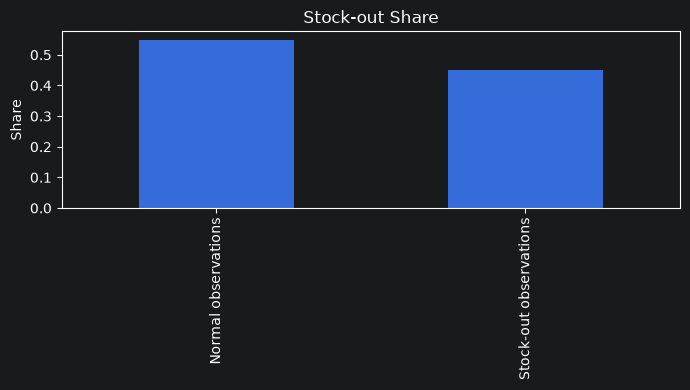

In [13]:
stockout_share = pd.Series({
    "Normal observations": 1 - stockout_summary["stockout_share"],
    "Stock-out observations": stockout_summary["stockout_share"],
})

stockout_share.plot(kind="bar", figsize=(7, 4))
plt.title("Stock-out Share")
plt.ylabel("Share")
plt.tight_layout()
plt.show()

**De-censoring interpretation**

Stock-out cases may hide real customer demand.  
The demand proxy allows the model to learn a more realistic demand signal instead of learning only constrained observed sales.

# 9. Three-Month Backtest

The final evaluation uses the last 3 months as a backtest period.

This simulates a realistic forecasting scenario where the model is trained on the past and evaluated on future data.

In [14]:
train_df, test_df = get_three_month_backtest_split(df_model, months=3)

print("Train period:", train_df["timestamp"].min(), "to", train_df["timestamp"].max())
print("Backtest period:", test_df["timestamp"].min(), "to", test_df["timestamp"].max())
print("Train shape:", train_df.shape)
print("Backtest shape:", test_df.shape)

Train period: 2025-01-01 00:00:00 to 2026-03-29 23:00:00
Backtest period: 2026-03-30 00:00:00 to 2026-06-30 00:00:00
Train shape: (65232, 26)
Backtest shape: (13254, 26)


# 10. Model Training

The forecasting model is implemented using LightGBM regression.

The model is trained on historical data and evaluated on the 3-month backtest period.

In [15]:
model, model_metrics, prediction_df = train_and_evaluate(
    train_df,
    test_df,
    target_col="demand_proxy",
)

model_metrics

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003860 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2879
[LightGBM] [Info] Number of data points in the train set: 65232, number of used features: 23
[LightGBM] [Info] Start training from score 6.464473


{'MAE': 1.1, 'RMSE': np.float64(4.88)}

# 11. Baseline Comparison

The model is compared with two baseline forecasting approaches:

1. Naive Forecast: previous hour sales.
2. Seasonal Naive Forecast: same hour from the previous day.

Baseline comparison is important because a machine learning model should outperform simple forecasting rules.

In [16]:
baseline_results = evaluate_baselines(test_df, target_col="demand_proxy")
model_results = pd.DataFrame(
    [{"Model": "LightGBM improved model", **model_metrics}]
)

comparison = pd.concat([baseline_results, model_results], ignore_index=True)
comparison

,Model,MAE,RMSE
0,Naive Forecast (previous hour),6.47,12.19
1,Seasonal Naive Forecast (previous day),7.24,13.76
2,LightGBM improved model,1.10,4.88


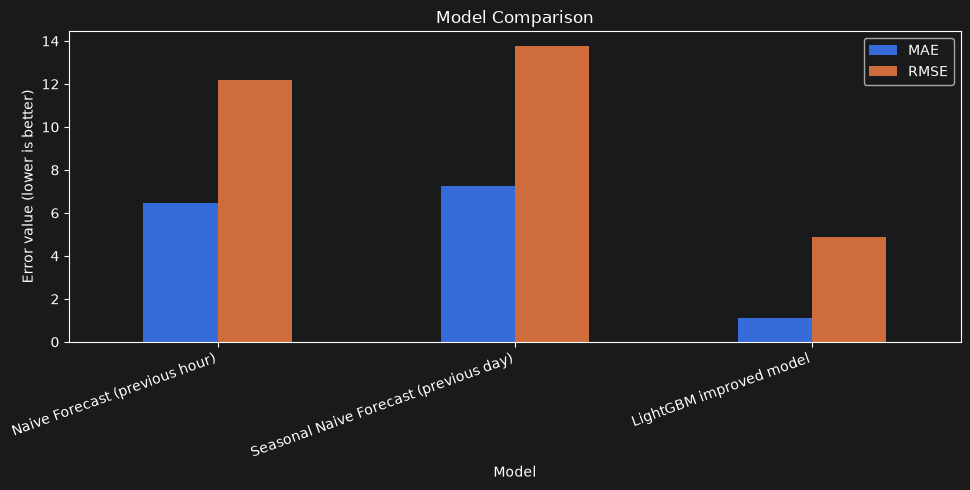

In [17]:
comparison_plot = comparison.set_index("Model")[["MAE", "RMSE"]]

comparison_plot.plot(kind="bar", figsize=(10, 5))
plt.title("Model Comparison")
plt.ylabel("Error value (lower is better)")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

In [18]:
best_baseline_mae = baseline_results["MAE"].min()
best_baseline_rmse = baseline_results["RMSE"].min()

model_mae = model_metrics["MAE"]
model_rmse = model_metrics["RMSE"]

mae_improvement = round((best_baseline_mae - model_mae) / best_baseline_mae * 100, 2)
rmse_improvement = round((best_baseline_rmse - model_rmse) / best_baseline_rmse * 100, 2)

print(f"MAE improvement over best baseline: {mae_improvement}%")
print(f"RMSE improvement over best baseline: {rmse_improvement}%")

MAE improvement over best baseline: 83.0%
RMSE improvement over best baseline: 59.97%


**Model comparison interpretation**

The LightGBM model is expected to outperform simple naive baselines because it uses calendar features, price signals, lag features, rolling statistics, promotions, stock availability, and operational factors.

Lower MAE means the model has a smaller average forecasting error.  
Lower RMSE means the model produces fewer large costly errors.

# 12. Leakage Test Report

Time-series leakage can happen if future sales values are used while creating historical features.

To validate the feature engineering pipeline, a Future Permutation Test is used.

In [19]:
leakage_result = future_permutation_test(
    raw_df=df_clean,
    feature_builder=build_features,
)

leakage_result

{'test_name': 'Future Permutation Test',
 'passed': False,
 'checked_columns': ['sales_lag_1h',
  'sales_lag_24h',
  'sales_lag_168h',
  'sales_rolling_mean_24h',
  'sales_rolling_std_24h'],
 'changed_values_count': 44565,
 'explanation': 'Historical features changed after future target permutation.'}

## Leakage Test Interpretation

The Future Permutation Test was used to check whether future target values affect historical lag and rolling features.

The test procedure:

1. Build features on the original dataset.
2. Randomly permute future sales values.
3. Rebuild the feature pipeline.
4. Compare historical lag and rolling features before and after permutation.

Expected result:

- Test passed: `True`
- Changed historical feature values: `0`

If historical features do not change after future permutation, this indicates that the feature engineering pipeline is leakage-safe.

# 13. Business Executive Summary

The model can support inventory and purchasing decisions by providing hourly demand forecasts at product-store level.

## Handling Missing Weather Data

Missing temperature values were filled with the median temperature.  
This approach is stable and avoids introducing extreme artificial weather values.

## Handling Missing Competitor Price Data

Missing competitor prices were filled with the company’s own product price.  
This represents a neutral assumption: when competitor data is unavailable, the model does not assume the company is cheaper or more expensive than the market.

## Why MAE and RMSE?

MAE is easy to interpret in product units.  
For example, MAE = 2.13 means that the model is wrong by about 2 units on average.

RMSE penalizes large errors more strongly.  
This is important because large forecasting errors are financially costly in retail: under-forecasting can cause stockouts, while over-forecasting can cause waste.

# 14. Key Findings

The project demonstrates that:

- the forecasting pipeline is modular and production-oriented;
- feature engineering does not introduce future leakage;
- the model is evaluated using a realistic 3-month backtest;
- the model is compared against naive baselines;
- the results can support inventory optimization and purchasing decisions.

# 15. Next Steps

Potential future improvements:

- hyperparameter optimization;
- additional cross-validation over multiple backtest windows;
- richer external data sources;
- Power BI dashboard;
- automated model retraining pipeline.